<a href="https://colab.research.google.com/github/amkathum/-Colab/blob/main/DataCleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://i.imgur.com/Y2YppNk.png)

# AI Center - Islamic University of Madinah
# AI Training Program, Nov 2025
# Session 3: Data Cleaning

# Titanic Dataset - Complete Data Pre-processing Pipeline

In [ ]:
# numpy ---> arrays
# pandas --> dataframes
# matplotlib --> plots
# sklearn --> preprocessing + models + metrics + data splitting (train_test_split, KFold, StratifiedKFold)

# preprocessing --> preparing the data to be enternted into model
#   Encoding
#   Standardization
#   imputation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

##  Load and Inspect Data

In [11]:
df_titanic = pd.read_csv('/content/train.csv')

print("Dataset shape:", df_titanic.shape)
df_titanic.head()


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
Features Engineering

SyntaxError: invalid syntax (477589255.py, line 1)

In [13]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Identify Missing Values

In [15]:
df_titanic.isnull().sum() / len(df_titanic)

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Missing values summary:
          Missing_Count  Percentage
Cabin               687   77.104377
Age                 177   19.865320
Embarked              2    0.224467


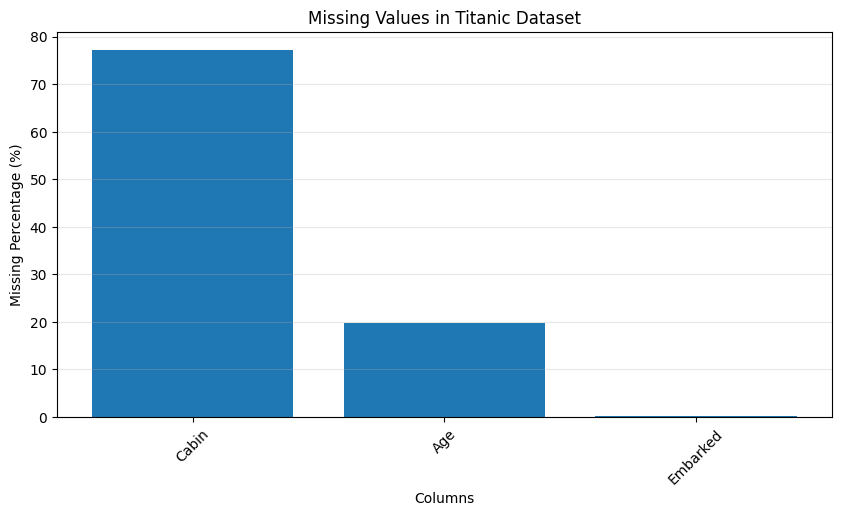

In [16]:
missing_values = df_titanic.isnull().sum()
missing_percent = (missing_values / len(df_titanic)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing values summary:")
print(missing_df)

plt.figure(figsize=(10, 5))
plt.bar(missing_df.index, missing_df['Percentage'])
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.title('Missing Values in Titanic Dataset')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Handle Missing Values

Different strategies for different columns:
- **Age**: Fill with median (numerical, sensitive to outliers)
- **Embarked**: Fill with mode (categorical, few missing)
- **Cabin**: Drop (too many missing values - 77%)

In [17]:
df_titanic_clean = df_titanic.copy()

df_titanic_clean['Age'].fillna(df_titanic_clean['Age'].median(), inplace=True)
df_titanic_clean['Embarked'].fillna(df_titanic_clean['Embarked'].mode()[0], inplace=True)
df_titanic_clean.drop('Cabin', axis=1, inplace=True)

print("Missing values after cleaning:")
print(df_titanic_clean.isnull().sum())
print("\nShape after dropping Cabin:", df_titanic_clean.shape)

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Shape after dropping Cabin: (891, 11)


/tmp/ipykernel_4389/1447574209.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic_clean['Age'].fillna(df_titanic_clean['Age'].median(), inplace=True)
/tmp/ipykernel_4389/1447574209.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

## Check for Duplicates

In [18]:
# Split ---> train and test
# ML ---> train on the training data ---> evaluate on the test data


# Leakage(تسريب)

In [19]:
duplicates = df_titanic_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df_titanic_clean.drop_duplicates(inplace=True)
    print(f"Removed {duplicates} duplicate rows")
else:
    print("No duplicates found!")

Number of duplicate rows: 0
No duplicates found!


## Exploratory Data Analysis (EDA)

In [20]:
survival_counts = df_titanic_clean['Survived'].value_counts()
print("Survival distribution:")
print(survival_counts)
print(f"\nSurvival rate: {survival_counts[1] / len(df_titanic_clean) * 100:.2f}%")

Survival distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.38%


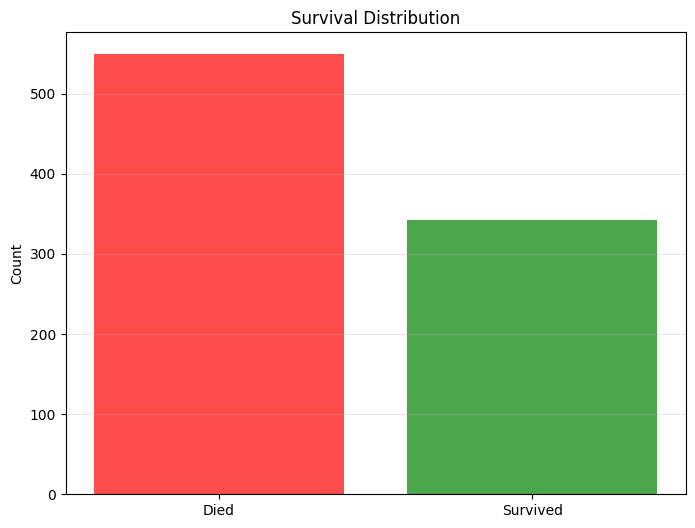

In [21]:
# Plot 1: Survival Distribution
plt.figure(figsize=(8, 6))
plt.bar(['Died', 'Survived'], survival_counts.values, color=['red', 'green'], alpha=0.7)
plt.title('Survival Distribution')
plt.ylabel('Count')
plt.grid(True, alpha=0.3, axis='y')
plt.show()


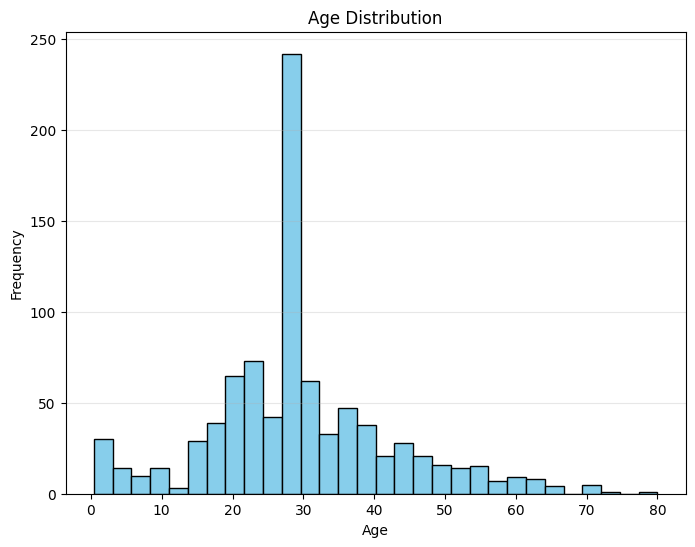

In [22]:
# Plot 2: Age Distribution
plt.figure(figsize=(8, 6))
plt.hist(df_titanic_clean['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

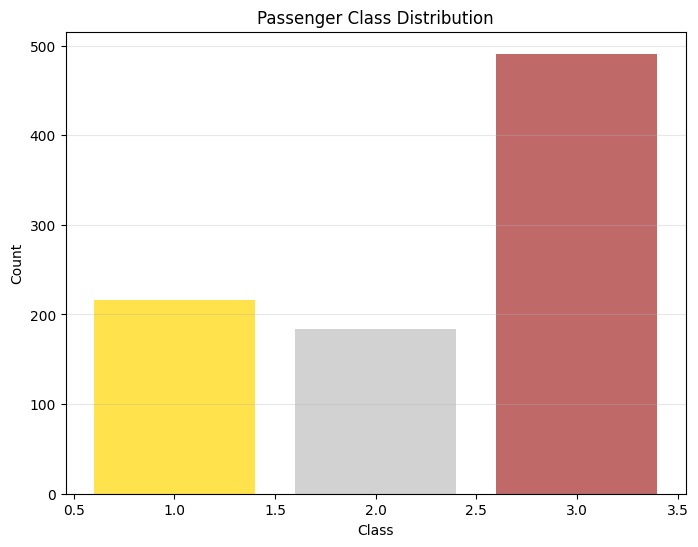

In [23]:
# Plot 3: Passenger Class Distribution
class_counts = df_titanic_clean['Pclass'].value_counts().sort_index()
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values, color=['gold', 'silver', 'brown'], alpha=0.7)
plt.title('Passenger Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

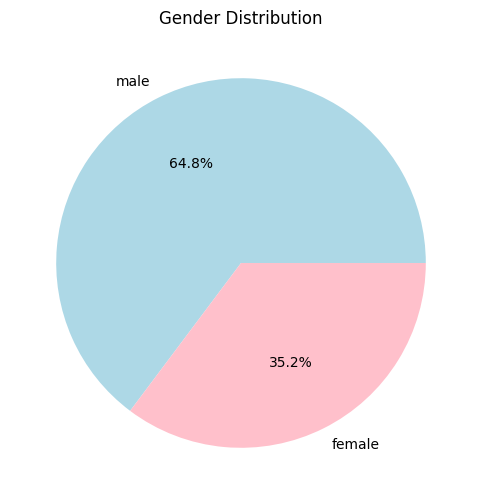

In [24]:
# Plot 4: Gender Distribution
sex_counts = df_titanic_clean['Sex'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', colors=['lightblue', 'pink'])
plt.title('Gender Distribution')
plt.show()

## Encoding Categorical Variables

**Why encoding?** Machine learning models work with numbers, not text. We need to convert categorical variables into numerical format.

In [32]:
df_titanic_clean[['Sex', 'Embarked', 'Name', 'Ticket']]




,Sex,Embarked,Name,Ticket
0,male,S,"Braund, Mr. Owen Harris",A/5 21171
1,female,C,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599
2,female,S,"Heikkinen, Miss. Laina",STON/O2. 3101282
3,female,S,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803
4,male,S,"Allen, Mr. William Henry",373450
...,...,...,...,...
886,male,S,"Montvila, Rev. Juozas",211536
887,female,S,"Graham, Miss. Margaret Edith",112053
888,female,S,"Johnston, Miss. Catherine Helen ""Carrie""",W./C. 6607
889,male,C,"Behr, Mr. Karl Howell",111369


In [31]:
for col in ['Sex', 'Embarked', 'Name', 'Ticket']:
    if col in df_titanic_clean.columns:
        unique_count = df_titanic_clean[col].nunique()
        print(f"  {col}: {unique_count} unique values")

df_encoded = df_titanic_clean.copy()


label_encoder = LabelEncoder()
df_encoded['Sex'] = label_encoder.fit_transform(df_encoded['Sex'])
df_encoded['Sex']


  Sex: 2 unique values
  Embarked: 3 unique values
  Name: 891 unique values
  Ticket: 681 unique values


,Sex
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [33]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df_encoded[['Embarked']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['Embarked']))
df_encoded = pd.concat([df_encoded, encoded_df], axis=1)

df_encoded.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,0.0,0.0,1.0


In [34]:
df_encoded.drop(['Name', 'Ticket', 'Embarked'], axis=1, inplace=True)
df_encoded.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,7.2500,0.0,0.0,1.0
1,2,1,1,0,38.0,1,0,71.2833,1.0,0.0,0.0
2,3,1,3,0,26.0,0,0,7.9250,0.0,0.0,1.0
3,4,1,1,0,35.0,1,0,53.1000,0.0,0.0,1.0
4,5,0,3,1,35.0,0,0,8.0500,0.0,0.0,1.0


## Feature Scaling

**Why scaling?** Features with larger ranges can dominate the learning process. Scaling brings all features to a similar range.

**Two common methods:**
- **Standardization** (StandardScaler): Centers data around mean=0, std=1
- **Normalization** (MinMaxScaler): Scales data to range [0, 1]

Before scaling:
              Age        Fare
count  891.000000  891.000000
mean    29.361582   32.204208
std     13.019697   49.693429
min      0.420000    0.000000
25%     22.000000    7.910400
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200

After StandardScaler (mean=0, std=1):
                Age          Fare
count  8.910000e+02  8.910000e+02
mean   2.272780e-16  3.987333e-18
std    1.000562e+00  1.000562e+00
min   -2.224156e+00 -6.484217e-01
25%   -5.657365e-01 -4.891482e-01
50%   -1.046374e-01 -3.573909e-01
75%    4.333115e-01 -2.424635e-02
max    3.891554e+00  9.667167e+00


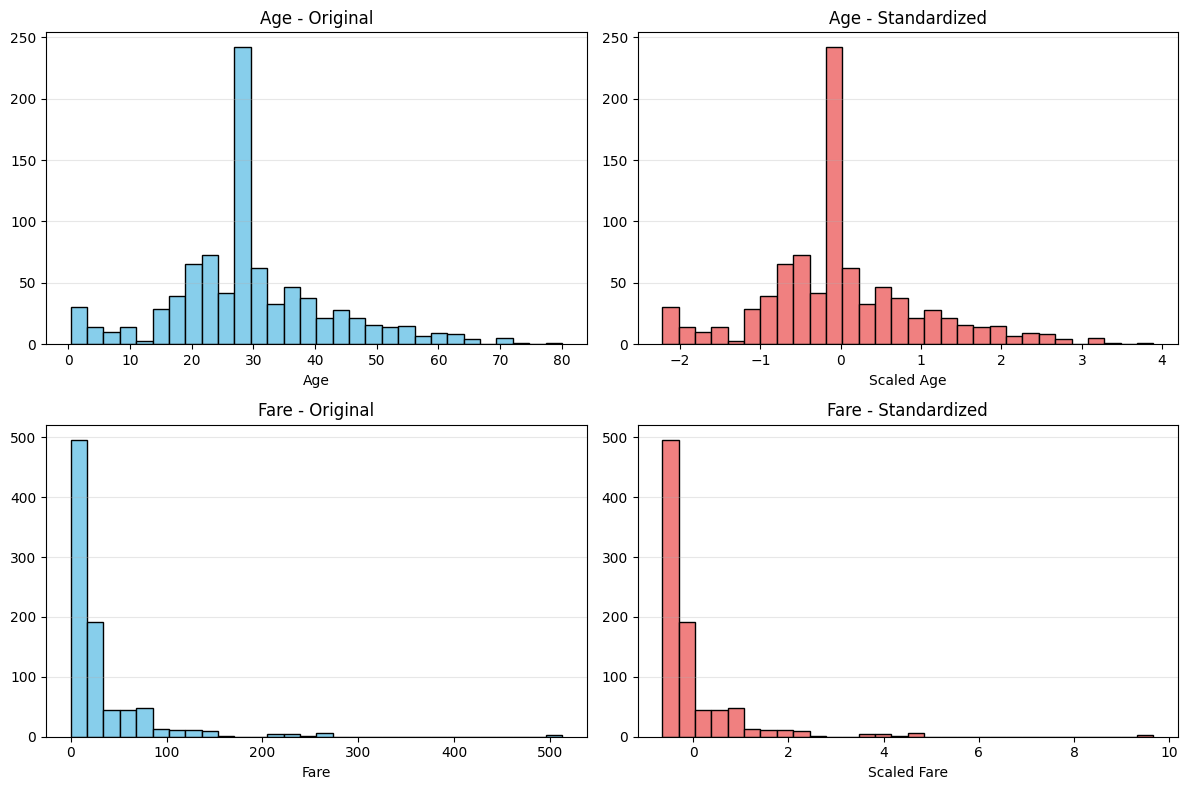

In [35]:
features_to_scale = ['Age', 'Fare']

print("Before scaling:")
print(df_encoded[features_to_scale].describe())

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print("\nAfter StandardScaler (mean=0, std=1):")
print(df_scaled[features_to_scale].describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_encoded['Age'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age - Original')
axes[0, 0].set_xlabel('Age')
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].hist(df_scaled['Age'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Age - Standardized')
axes[0, 1].set_xlabel('Scaled Age')
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].hist(df_encoded['Fare'], bins=30, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Fare - Original')
axes[1, 0].set_xlabel('Fare')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].hist(df_scaled['Fare'], bins=30, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Fare - Standardized')
axes[1, 1].set_xlabel('Scaled Fare')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Exercise - Adult Census Income Dataset

Now it's your turn! Apply everything you've learned to prepare the Adult Census Income dataset.

**Dataset Info:**
- Predict whether income exceeds $50K/yr based on census data
- Mix of numerical and categorical features
- Contains missing values marked as '?'

## Load Data

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/adult-census-income")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'adult-census-income' dataset.
Path to dataset files: /kaggle/input/adult-census-income


In [41]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3/adult.csv')

print("Dataset shape:", df.shape)
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3/adult.csv'